In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
boxsize=205

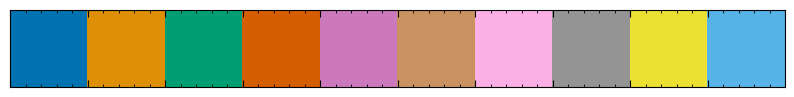

In [5]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [6]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [7]:

tng_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all/mvir"

tng_data1 = np.loadtxt(f"{tng_dir}/sfr-halomass_central.txt")



In [8]:
tng_data2 = np.loadtxt(f"{tng_dir}/sfr-halomass_satellite.txt")

In [9]:
def read_data(sim_dir, mass_min=0):
    sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")
 
    mhalo_sim1 = sim_data1[:,0]
    pos_sim1 = sim_data1[:,1:4]
    sfr_sim1 = sim_data1[:,4]


    mask_min = mhalo_sim1 > mass_min
    return mhalo_sim1[mask_min], pos_sim1[mask_min], sfr_sim1[mask_min]

In [10]:
mask_min = tng_data1[:,0] > 0
mhalo_tng1 = tng_data1[:,0][mask_min]
pos_tng1 = tng_data1[:,1:4][mask_min]
sfr_tng1 = tng_data1[:,4][mask_min]

In [11]:
mask_min = tng_data2[:,0] > 0
mhalo_tng2 = tng_data2[:,0][mask_min]
pos_tng2 = tng_data2[:,1:4][mask_min]
sfr_tng2= tng_data2[:,4][mask_min]

In [12]:
tng_data3 = np.loadtxt(f"{tng_dir}/sfr-halomass_sum.txt")

In [13]:
mask_min = tng_data3[:,1] > 0
mhalo_tng3 = tng_data3[:,0][mask_min]
pos_tng3 = tng_data3[:,1:4][mask_min]
sfr_tng3 = tng_data3[:,4][mask_min]

In [14]:
dr = 1
pos1 = pos_tng1[mask_max][0]
pos_tng_test = pos_tng2
mask_sat = (pos_tng_test[:,0] < pos1[0]+dr) & (pos_tng_test[:,0] > pos1[0]-dr) & (pos_tng_test[:,1] < pos1[1]+dr) & (pos_tng_test[:,1] > pos1[1]-dr) & (pos_tng_test[:,2] < pos1[2]+dr) & (pos_tng_test[:,2] > pos1[2]-dr) 


NameError: name 'mask_max' is not defined

In [15]:
def gen_sums(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums = np.sum(10**sfr[mask])
        sums_list[ibin] = sums
    return bin_cents, np.array(sums_list), total

In [16]:
def create_stairs_plot(x_edges, y, label=None, data_type="sfr", color=None):
    fig, ax = plt.subplots()
    plt.stairs(y, x_edges, label=label, color=color) # need newer matplotlib/python
    ax.set_ylabel(r"SFR$_{\rm{bin}}$ / SFR$_{\rm{tot}}$")
    if data_type == "sfr":
        ax.set_xlabel(r"log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])")
    elif data_type == "mass":  
        ax.set_xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])')
    elif data_type == "mvir":  
        ax.set_xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
    return ax

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2208783/2238669538.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])')
/tmp/ipykernel_2208783/2238669538.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')


In [17]:
bin_edges_sfr = np.arange(-3.5, 4, 0.5)
bin_cents, sums_cent, total_cent = gen_sums(sfr_tng1, bin_edges_sfr)
bin_cents, sums_sat, total_sat = gen_sums(sfr_tng2, bin_edges_sfr)
bin_cents, sums_group, total_group = gen_sums(sfr_tng3, bin_edges_sfr)

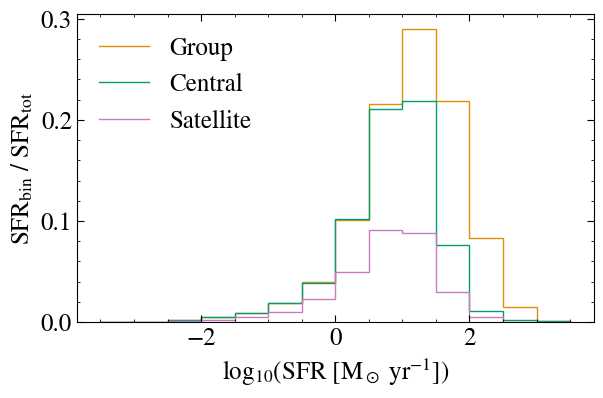

In [18]:
create_stairs_plot(bin_edges_sfr, sums_group/(total_group), label="Group", color=color_list[0])
plt.stairs(sums_cent/(total_group), bin_edges_sfr, label="Central", color=color_list[1])
plt.stairs(sums_sat/(total_group), bin_edges_sfr, label="Satellite", color=color_list[2])
plt.legend(loc="upper left")

#plt.savefig("figures/contribution_sfr_bins.pdf", format="pdf", bbox_inches="tight")

### Mass bins

In [19]:
bin_edges_mhalo = np.arange(9, 14.4, 0.5)
bin_cents, sums_cent, total_cent = gen_sums(sfr_tng1, bin_edges_mhalo, mhalo_tng1)
bin_cents, sums_sat, total_sat = gen_sums(sfr_tng2, bin_edges_mhalo, mhalo_tng2)
bin_cents, sums_group, total_group = gen_sums(sfr_tng3, bin_edges_mhalo, mhalo_tng3)

In [20]:
plt.rcParams["xtick.minor.size"] = 4

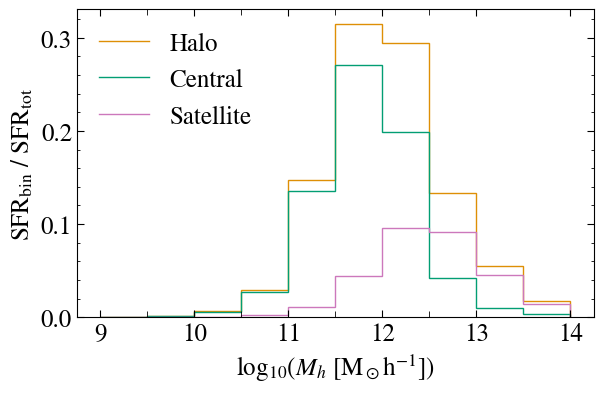

In [23]:
ax = create_stairs_plot(bin_edges_mhalo, sums_group/(total_group), label="Halo", data_type="mvir", color=color_list[0])
plt.stairs(sums_cent/(total_group), bin_edges_mhalo, label="Central", color=color_list[1])
plt.stairs(sums_sat/(total_group), bin_edges_mhalo, label="Satellite", color=color_list[2])
plt.legend(loc="upper left")
#plt.minor_xticks(np.arange(9,13.5,0.5))
plt.xlabel(r"log$_{10}(M_h$ [M$_\odot$h$^{-1}$])")

ax.set_xticks(np.arange(9.5,13.5,1), minor=True)

#plt.savefig("../figures/contribution_mvir_bins.pdf", format="pdf", bbox_inches="tight")

In [ ]:
#create_stairs_plot(bin_edges, sums_cent/(total_cent), label="central")
create_stairs_plot(bin_edges, sums_sat/(total_sat), label="satellite")
#plt.stairs(sums_sat/(total_sat), bin_edges, label="satellite")
plt.legend()